# 2.2、控制流并行展示

对比并行和串行执行是将，两个节点串行5s170ms, 并行4s422ms

In [8]:
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
load_dotenv(override=True)

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


{'topic': '猫咪', 'poem': '## 《猫咪》\n\n它的脚步像黄昏的笔尖，\n多一分倾斜就踩碎寂静。\n整个下午，阴影在沙发角落\n调整姿态，等它安眠。\n\n它舔着前爪，却在我眼底\n留下绒毛般的信号。\n偶尔跃上书架，抖落\n半阕宋词，或者\n完整的一个哈欠。\n\n厨房飘来鱼腥时，\n它眯起眼睛，仿佛在运算\n我手尖到碗底的距离。\n每走近一步，就用尾巴\n划出新的钟表。\n\n夜，垂落时它蹲在窗口，\n像被拆封的默片，只投递\n两个绿月亮。\n\n如果它突然跳下，水银\n在六条腿上，很快地\n碎了一地凉。', 'joke': '一个小孩问爸爸：“爸爸，猫咪为什么不喜欢洗澡？”  \n爸爸想了想说：“因为它们怕水，而且觉得洗澡是在破坏它们的‘高级皮毛造型’。”  \n小孩又问：“那为什么它们又喜欢用舌头舔自己呢？”  \n爸爸笑着说：“因为那是猫咪自己的‘干洗套餐’，还自带护发素呢！”'}


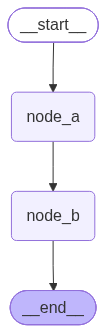

In [9]:
from typing import TypedDict
from IPython.display import display
from langgraph.graph import StateGraph, START, END

# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str


# 2、定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(f"请写一个关于{state["topic"]}的诗").content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(f"请写一个关于{state["topic"]}的笑话").content
    return {
        "joke": joke
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_edge(START, "node_a")
builder.add_sequence([node_a, node_b])
builder.add_edge("node_b", END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪"})
print(res)

display(graph)

{'topic': '猫咪', 'poem': '## 《午后的猫》\n\n青石板上，一摊流动的斑影\n使正午的静止变得具体。\n当你观察它，这片浓荫是\n你养的一池水。沉入就是上升。\n它被它自身所打扰，有时\n伸出茸茸的爪子，来抓停摆的钟。\n而当一个女孩蹲下身子，轻轻\n“喵”了一声，它就回头——如此古老\n犹如新月注视着一场战役。\n和离弦之箭没什么两样，\n它追逐自己的尾巴。\n它把睡意当作最软的剑鞘\n把窗台上的蝴蝶当作不会结束的夏天。\n但你数不清：一只还是无数只\n分散在庭院里。因为每一只\n都是时间的眼，而时间只有瞪圆。', 'joke': '这是一个关于猫咪的冷笑话，希望你喜欢：\n\n**养了一只特别懒的猫，每天除了睡就是吃。**\n**有一天，我实在忍不住教育它：**\n**“你看看隔壁的狗，每天看家护院，早上还叫主人起床，多有出息！”**\n\n**猫懒洋洋地睁开一只眼，打了个哈欠说：**\n**“它那么能干，不也没住进我主人的心里吗？我光靠一张脸，就让你自愿铲屎、买罐头、还天天抱抱。到底是谁赚了？”**\n\n**我……我竟无言以对。** 😼'}


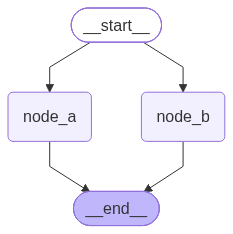

In [10]:
from typing import TypedDict

from IPython.display import display
from langgraph.graph import StateGraph, START, END



# 1、定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str


# 2、定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(f"请写一个关于{state["topic"]}的诗").content
    return {
        "poem": poem
    }


def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(f"请写一个关于{state["topic"]}的笑话").content
    return {
        "joke": joke
    }


# 3、构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")
builder.add_edge("node_b", END)
builder.add_edge("node_a", END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪"})
print(res)

display(graph)